# Introducción al Machine Learning

**Unidad 9 · Machine Learning · Notebook 0 de 6**

Este notebook no entrena ningún modelo. Establece el marco conceptual y el vocabulario que
los cinco notebooks siguientes van a usar sin volver a explicar.

## ¿Por qué una unidad de Machine Learning en una materia de opinión pública?

Las ocho unidades anteriores construyeron un aparato para **explicar**: estimar un
parámetro, ponerle un intervalo de confianza, testear una hipótesis, aislar el efecto de
una variable de las demás. La pregunta que organizaba todo era *¿cuál es el efecto de X
sobre Y, y cuán seguros estamos?*

El machine learning organiza el trabajo alrededor de otra pregunta: *¿qué tan bien puedo
anticipar Y en casos que todavía no vi?* No es una pregunta mejor ni más moderna. Es
distinta, y cambia qué cuenta como éxito.

Un ejemplo concreto de la diferencia. Si estimamos un modelo de intención de voto:

- Al **investigador** le interesa cuánto pesa el nivel educativo controlando por edad e
  ingreso, y si ese coeficiente es distinguible de cero.
- Al **analista de campaña** le interesa poder decir, para cada uno de los 200.000 registros
  de una base, cuál es la probabilidad de que esa persona vote a su candidato — sin
  importarle demasiado por qué.

El segundo problema es de machine learning. Y aparece constantemente en el trabajo real del
analista de opinión pública: segmentar un padrón, imputar respuestas faltantes, priorizar a
quién llamar en un relevamiento, detectar qué mesas se comportan distinto de lo esperado.

## Las dos culturas

Leo Breiman, estadístico de Berkeley, describió esta tensión en 2001 en un artículo
llamado *Statistical Modeling: The Two Cultures*. Su planteo, resumido:

| | **Cultura del modelo de datos** | **Cultura del modelo algorítmico** |
|---|---|---|
| Supuesto | los datos vienen de un modelo estocástico conocido | el mecanismo que genera los datos es desconocido |
| Objetivo | estimar bien los parámetros de ese modelo | predecir bien la respuesta |
| Se valida | con tests de bondad de ajuste y de supuestos | con error de predicción sobre datos no vistos |
| Herramientas | regresión lineal, logística, modelos paramétricos | árboles, ensambles, redes neuronales |
| Qué se sacrifica | flexibilidad | interpretabilidad |
| Unidades | 0 a 8 de esta materia | esta unidad |

Las dos son legítimas y las dos tienen puntos ciegos. La primera puede estar estimando con
mucha precisión los parámetros de un modelo que no describe la realidad. La segunda puede
predecir muy bien sin decir nada sobre por qué.

En ciencia política el punto ciego de la segunda cultura pesa mucho: si el resultado tiene
que sostener un argumento sobre causas, un modelo que predice bien y no se puede
interpretar sirve poco. Por eso a lo largo de la unidad vamos a insistir en la
**interpretabilidad** tanto como en la performance, y a mostrar en cada método qué se puede
y qué no se puede afirmar con él.

## Requisitos

Este notebook usa solo librerías del ecosistema científico estándar. La celda siguiente
**no instala nada**: lista lo que hace falta y verifica qué tenés en tu entorno. Si algo
falta, instalalo vos y reiniciá el kernel.

In [1]:
# Requisitos de este notebook.
# Si te falta alguno, instalalo EN TU PROPIO ENTORNO desde una terminal
# (o descomentando la linea de abajo) y reinicia el kernel:
#
#     pip install numpy pandas matplotlib seaborn scikit-learn statsmodels
#
# %pip install numpy pandas matplotlib seaborn scikit-learn statsmodels

import importlib

_requeridos = ['numpy', 'pandas', 'matplotlib', 'seaborn', 'sklearn', 'statsmodels']
_faltan = []
for _m in _requeridos:
    try:
        _mod = importlib.import_module(_m)
        print(f"  {_m:16s} {getattr(_mod, '__version__', 'sin version')}")
    except ImportError:
        _faltan.append(_m)
        print(f"  {_m:16s} FALTA")

if _faltan:
    print(f"\nFaltan {len(_faltan)} paquetes: {', '.join(_faltan)}.")
    print("Instalalos en tu entorno antes de seguir.")
else:
    print("\nTodo listo.")

  numpy            1.26.4
  pandas           2.2.2
  matplotlib       3.9.2


  seaborn          0.13.2
  sklearn          1.9.0
  statsmodels      0.14.2

Todo listo.


## Librerías

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.width", 200)

SEED = 42
rng = np.random.default_rng(SEED)

PALETA = ["#0073C2", "#EFC000", "#CD534C", "#868686", "#1E2749"]

## El mapa del terreno

La división canónica del machine learning es por **qué información tiene disponible el
algoritmo**:

<figure style="text-align:center; margin:1.5em 0;">
  <img src="media/MLtypes.png" width="780">
  <figcaption style="font-size:0.9em; color:#555;">
    Los tres tipos de aprendizaje y sus tareas típicas.
  </figcaption>
</figure>

Leído de izquierda a derecha:

- **Supervisado** — el algoritmo recibe ejemplos con la respuesta correcta incluida
  (*datos etiquetados*) y aprende a reproducirla en casos nuevos.
- **No supervisado** — no hay respuesta correcta. El algoritmo busca estructura en los
  datos por sí solo.
- **Por refuerzo** — un agente toma acciones en un entorno, recibe una recompensa y ajusta
  su comportamiento para maximizarla a lo largo del tiempo.

Ese orden —supervisado, no supervisado, por refuerzo— es el de esta unidad.

### Lo que el diagrama deja afuera

El esquema es el estándar, pero está incompleto en la rama no supervisada: muestra
únicamente *clustering*. Hay al menos dos tareas no supervisadas más que importan, y una de
ellas es un notebook entero de esta unidad:

- **Reglas de asociación**: encontrar qué cosas ocurren juntas más de lo esperable por
  azar. Es el notebook `9.5`.
- **Reducción de dimensionalidad**: describir muchas variables con unas pocas
  combinaciones de ellas. Aparece en `9.4` como herramienta de visualización (PCA).

Este es el mapa completo, con la ubicación de cada notebook de la unidad:

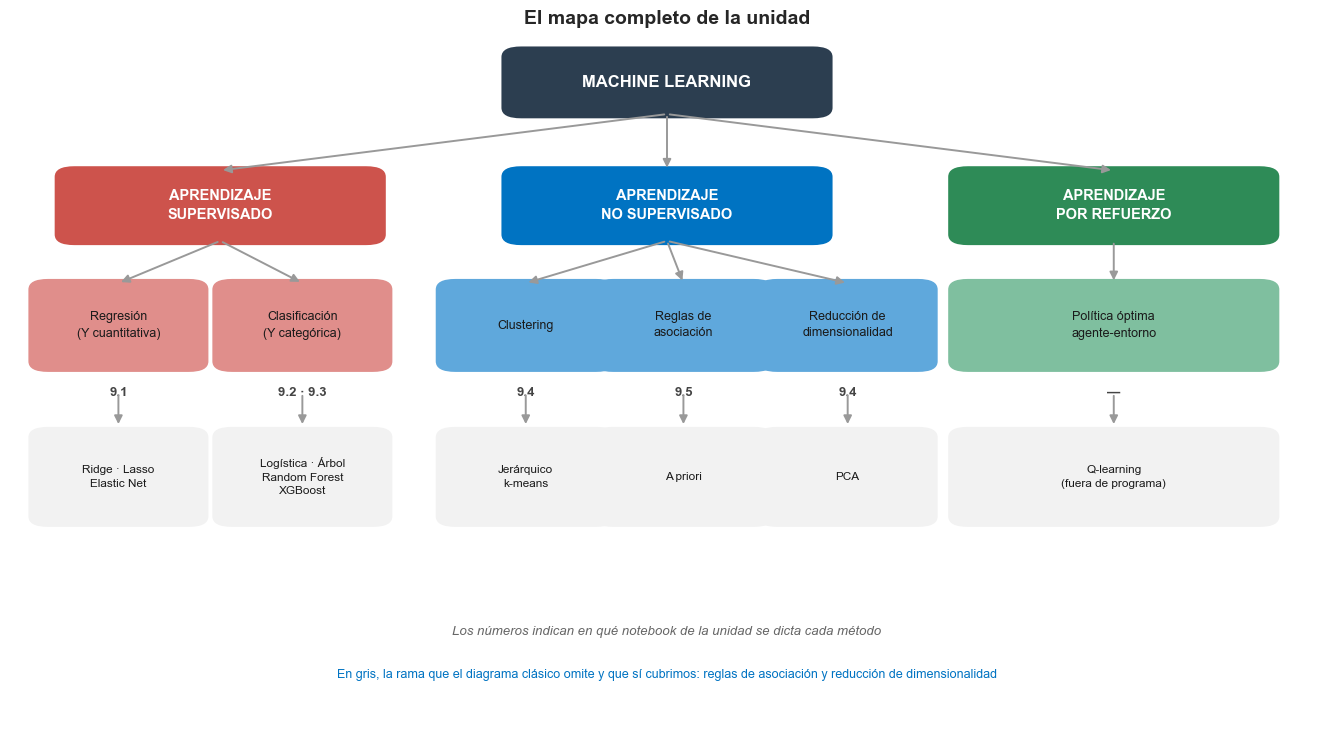

In [3]:
fig, ax = plt.subplots(figsize=(13.5, 7.6))
ax.set_xlim(0, 100); ax.set_ylim(0, 100); ax.axis("off")

def caja(x, y, w, h, texto, color, size=10, peso="normal", tcolor="white"):
    ax.add_patch(mpatches.FancyBboxPatch(
        (x, y), w, h, boxstyle="round,pad=0.6,rounding_size=1.5",
        facecolor=color, edgecolor="none"))
    ax.text(x + w/2, y + h/2, texto, ha="center", va="center",
            fontsize=size, color=tcolor, fontweight=peso, linespacing=1.45)

def flecha(x1, y1, x2, y2):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="-|>", color="#999", lw=1.4,
                                shrinkA=2, shrinkB=2))

caja(38, 88, 24, 9, "MACHINE LEARNING", "#2C3E50", 12, "bold")

ramas = [("APRENDIZAJE\nSUPERVISADO", 4, "#CD534C"),
         ("APRENDIZAJE\nNO SUPERVISADO", 38, "#0073C2"),
         ("APRENDIZAJE\nPOR REFUERZO", 72, "#2E8B57")]
for texto, x, color in ramas:
    caja(x, 70, 24, 10, texto, color, 10.5, "bold")
    flecha(50, 88, x + 12, 80)

hojas = [
    # supervisado
    ("Regresión\n(Y cuantitativa)", 2, 52, "#E08E8B", "9.1"),
    ("Clasificación\n(Y categórica)", 16, 52, "#E08E8B", "9.2 · 9.3"),
    # no supervisado
    ("Clustering", 33, 52, "#5FA8DC", "9.4"),
    ("Reglas de\nasociación", 45, 52, "#5FA8DC", "9.5"),
    ("Reducción de\ndimensionalidad", 57.5, 52, "#5FA8DC", "9.4"),
    # refuerzo
    ("Política óptima\nagente-entorno", 72, 52, "#7FBF9F", "—"),
]
for texto, x, y, color, nb in hojas:
    w = 12.5 if x < 70 else 24
    caja(x, y, w, 12, texto, color, 9, tcolor="#1a1a1a")
    ax.text(x + w/2, y - 3.6, nb, ha="center", va="center", fontsize=9.5,
            color="#444", fontweight="bold")

for x, w in [(2, 12.5), (16, 12.5)]:
    flecha(16, 70, x + w/2, 64)
for x, w in [(33, 12.5), (45, 12.5), (57.5, 12.5)]:
    flecha(50, 70, x + w/2, 64)
flecha(84, 70, 84, 64)

metodos = [
    ("Ridge · Lasso\nElastic Net", 2, 30, 12.5),
    ("Logística · Árbol\nRandom Forest\nXGBoost", 16, 30, 12.5),
    ("Jerárquico\nk-means", 33, 30, 12.5),
    ("A priori", 45, 30, 12.5),
    ("PCA", 57.5, 30, 12.5),
    ("Q-learning\n(fuera de programa)", 72, 30, 24),
]
for texto, x, y, w in metodos:
    caja(x, y, w, 13, texto, "#F2F2F2", 8.5, tcolor="#1a1a1a")
    flecha(x + w/2, y + 18.4, x + w/2, y + 13.6)

ax.text(50, 14, "Los números indican en qué notebook de la unidad se dicta cada método",
        ha="center", fontsize=9.5, color="#666", style="italic")
ax.text(50, 8, "En gris, la rama que el diagrama clásico omite y que sí cubrimos: "
               "reglas de asociación y reducción de dimensionalidad",
        ha="center", fontsize=9, color="#0073C2")

ax.set_title("El mapa completo de la unidad", fontsize=14, fontweight="bold", pad=4)
plt.tight_layout()
plt.show()

## Aprendizaje supervisado

Tenemos $n$ observaciones. Para cada una conocemos un vector de **variables predictoras**
$x_i$ (también llamadas *features*, atributos o covariables) y una **etiqueta** $y_i$, que
es lo que queremos aprender a anticipar.

$$ \{(x_1, y_1), (x_2, y_2), \dots, (x_n, y_n)\} $$

El objetivo es encontrar una función $\hat{f}$ tal que $\hat{f}(x) \approx y$ **para casos
nuevos**, no para los que ya vimos. Esa última cláusula es todo el problema, y volveremos
sobre ella.

La palabra "supervisado" viene de que hay una respuesta correcta contra la cual corregirse.
En la práctica, esa etiqueta suele ser lo más caro del proyecto: alguien tuvo que
encuestar, codificar o clasificar a mano cada caso.

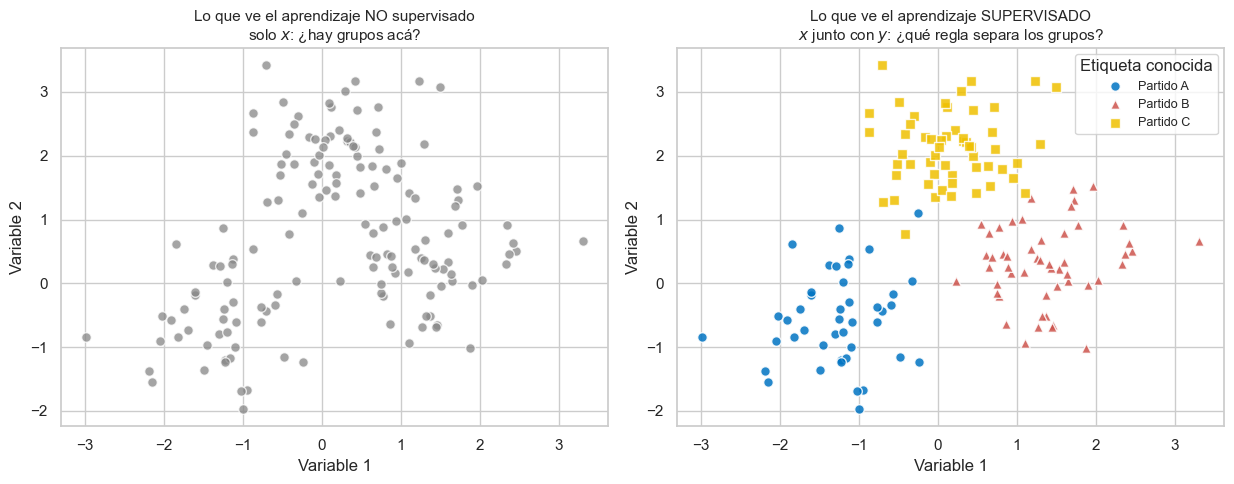

In [4]:
# Dos veces los mismos datos: con etiqueta y sin etiqueta
centros = np.array([[-1.4, -0.7], [1.5, 0.4], [0.2, 2.1]])
grupo = rng.integers(0, 3, 150)
Xd = centros[grupo] + rng.normal(scale=0.62, size=(150, 2))

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5))

axes[0].scatter(Xd[:, 0], Xd[:, 1], s=48, color=PALETA[3], alpha=0.75, edgecolor="white")
axes[0].set_title("Lo que ve el aprendizaje NO supervisado\n"
                  "solo $x$: ¿hay grupos acá?", fontsize=11)

for g, (color, marcador, nombre) in enumerate(zip(
        [PALETA[0], PALETA[2], PALETA[1]], ["o", "^", "s"],
        ["Partido A", "Partido B", "Partido C"])):
    m = grupo == g
    axes[1].scatter(Xd[m, 0], Xd[m, 1], s=48, color=color, marker=marcador,
                    alpha=0.85, edgecolor="white", label=nombre)
axes[1].legend(fontsize=9, title="Etiqueta conocida")
axes[1].set_title("Lo que ve el aprendizaje SUPERVISADO\n"
                  "$x$ junto con $y$: ¿qué regla separa los grupos?", fontsize=11)

for ax in axes:
    ax.set_xlabel("Variable 1"); ax.set_ylabel("Variable 2")
plt.tight_layout()
plt.show()

Los puntos son idénticos en los dos paneles. Lo único que cambia es la información
disponible, y eso cambia por completo la pregunta que se puede hacer:

- Sin etiqueta: *¿existen agrupamientos naturales?* La respuesta no tiene con qué
  verificarse — es una descripción de la estructura, y distintos métodos darán distintas
  respuestas defendibles.
- Con etiqueta: *¿qué regla asigna correctamente cada punto a su grupo?* Acá sí hay una
  respuesta correcta contra la que medirse.

### Las dos tareas supervisadas

Lo que decide la tarea es el **tipo de la etiqueta**:

- **Regresión** — $y$ es cuantitativa. Cuánto va a facturar una sucursal, qué porcentaje de
  votos obtiene un partido en un circuito, qué puntaje de corrupción tiene un país.
- **Clasificación** — $y$ es categórica. A qué partido se identifica un encuestado, si un
  país es democracia o autocracia, qué fuerza ganó una mesa.

La distinción no es cosmética: cambia la función que se minimiza, cambian las métricas y
cambian los métodos disponibles.

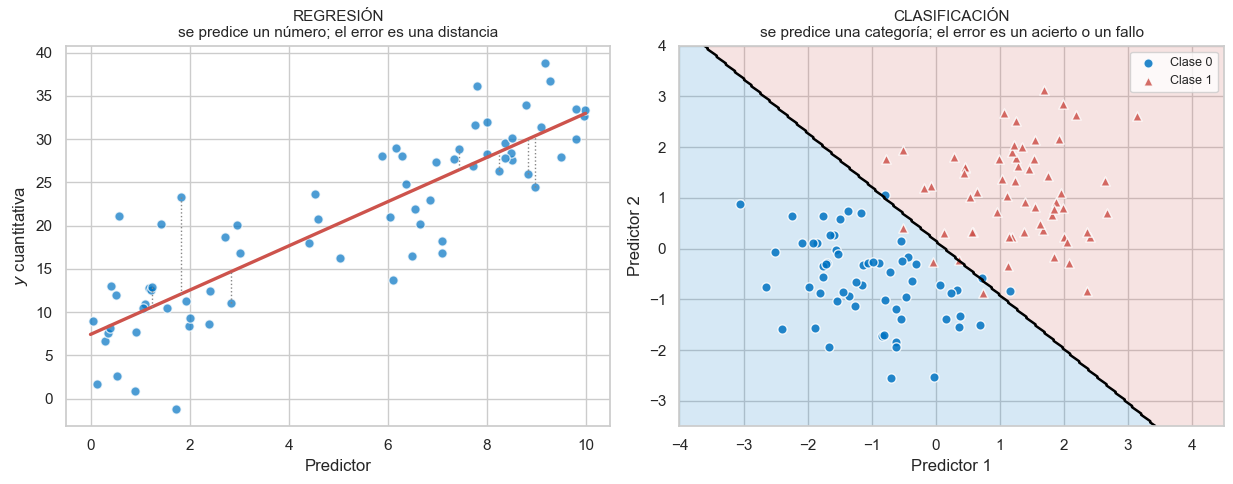

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 5))

# --- regresión
x = rng.uniform(0, 10, 70)
y = 2.4 * x + 8 + rng.normal(scale=4.5, size=70)
axes[0].scatter(x, y, s=45, color=PALETA[0], alpha=0.7, edgecolor="white")
xx = np.linspace(0, 10, 100)
b1, b0 = np.polyfit(x, y, 1)
axes[0].plot(xx, b0 + b1 * xx, color=PALETA[2], lw=2.4)
axes[0].set_xlabel("Predictor"); axes[0].set_ylabel("$y$ cuantitativa")
axes[0].set_title("REGRESIÓN\nse predice un número; el error es una distancia",
                  fontsize=11)
for i in rng.choice(70, 9, replace=False):
    axes[0].plot([x[i], x[i]], [y[i], b0 + b1 * x[i]], color=PALETA[3], lw=1, ls=":")

# --- clasificación
Xc = np.vstack([rng.normal([-1, -0.5], 0.85, (60, 2)),
                rng.normal([1.4, 1.1], 0.85, (60, 2))])
yc = np.r_[np.zeros(60), np.ones(60)]
clf = LogisticRegression().fit(Xc, yc)

g1, g2 = np.meshgrid(np.linspace(-4, 4.5, 300), np.linspace(-3.5, 4, 300))
Z = clf.predict(np.c_[g1.ravel(), g2.ravel()]).reshape(g1.shape)
axes[1].contourf(g1, g2, Z, alpha=0.16, colors=[PALETA[0], PALETA[2]], levels=[-0.5, 0.5, 1.5])
axes[1].contour(g1, g2, Z, levels=[0.5], colors="black", linewidths=1.8)
for k, (color, marcador) in enumerate(zip([PALETA[0], PALETA[2]], ["o", "^"])):
    m = yc == k
    axes[1].scatter(Xc[m, 0], Xc[m, 1], s=45, color=color, marker=marcador,
                    alpha=0.85, edgecolor="white", label=f"Clase {k}")
axes[1].legend(fontsize=9)
axes[1].set_xlabel("Predictor 1"); axes[1].set_ylabel("Predictor 2")
axes[1].set_title("CLASIFICACIÓN\nse predice una categoría; el error es un acierto o un fallo",
                  fontsize=11)

plt.tight_layout()
plt.show()

La diferencia clave está en cómo se mide el error. En regresión, errarle por 2 puntos es
mejor que errarle por 10: el error tiene magnitud. En clasificación, o acertaste la
categoría o no; y además **no todos los errores cuestan lo mismo** —clasificar a un votante
opositor como propio no tiene las mismas consecuencias que lo inverso—, lo que abre toda la
discusión de métricas que veremos más abajo.

La línea negra del panel derecho es la **frontera de decisión**. Los métodos de
clasificación se distinguen sobre todo por la forma que puede tomar esa frontera: recta en
la regresión logística (`9.2`), escalonada en los árboles (`9.3`).

## Aprendizaje no supervisado

No hay $y$. Solo tenemos $\{x_1, x_2, \dots, x_n\}$ y buscamos estructura.

Esto lo hace a la vez más libre y más difícil de evaluar: **no existe una respuesta
correcta contra la que comparar**. Un clustering no es "correcto" o "incorrecto"; es más o
menos útil e interpretable para la pregunta que se tiene entre manos. Por eso en estos
métodos el criterio sustantivo del investigador pesa más que cualquier métrica, algo sobre
lo que insistiremos en `9.4`.

Las tres tareas que cubre la unidad:

C:\Users\mmill\anaconda3\envs\PYR\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


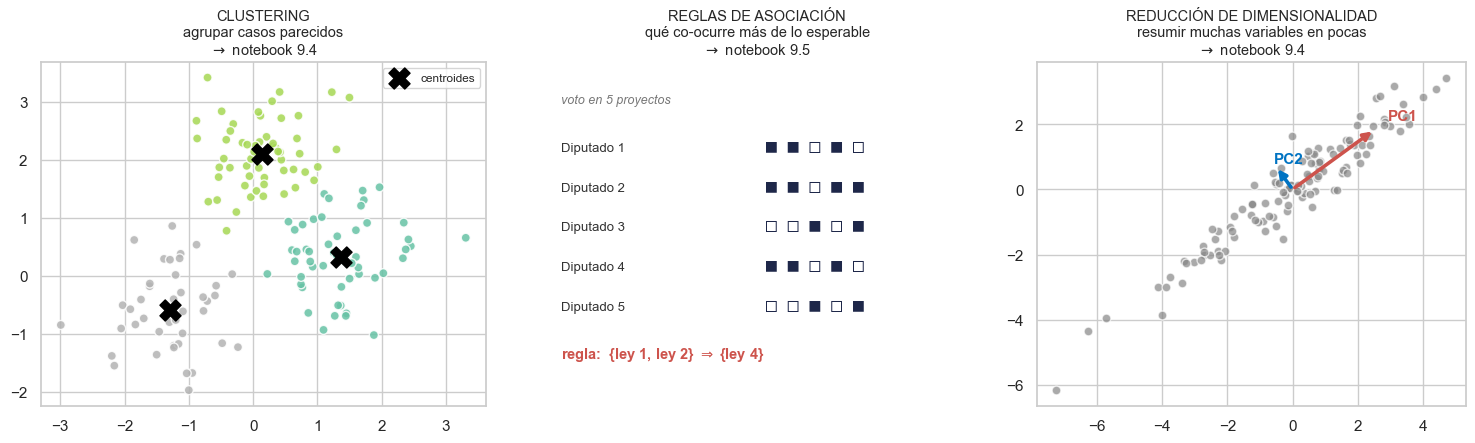

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))

# --- clustering
from sklearn.cluster import KMeans
km = KMeans(n_clusters=3, n_init=10, random_state=SEED).fit(Xd)
axes[0].scatter(Xd[:, 0], Xd[:, 1], c=km.labels_, cmap="Set2", s=42,
                alpha=0.85, edgecolor="white")
axes[0].scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
                marker="X", s=230, color="black", label="centroides")
axes[0].legend(fontsize=8.5)
axes[0].set_title("CLUSTERING\nagrupar casos parecidos\n$\\rightarrow$ notebook 9.4",
                  fontsize=10.5)

# --- reglas de asociación
axes[1].axis("off")
axes[1].set_title("REGLAS DE ASOCIACIÓN\nqué co-ocurre más de lo esperable\n"
                  "$\\rightarrow$ notebook 9.5", fontsize=10.5)
filas = [("Diputado 1", "■ ■ □ ■ □"), ("Diputado 2", "■ ■ □ ■ ■"),
         ("Diputado 3", "□ □ ■ □ ■"), ("Diputado 4", "■ ■ □ ■ □"),
         ("Diputado 5", "□ □ ■ □ ■")]
for k, (nombre, patron) in enumerate(filas):
    axes[1].text(0.06, 0.74 - k * 0.115, nombre, fontsize=9.5, color="#333")
    axes[1].text(0.52, 0.74 - k * 0.115, patron, fontsize=13, family="monospace",
                 color=PALETA[4])
axes[1].text(0.06, 0.88, "voto en 5 proyectos", fontsize=9, color="#777", style="italic")
axes[1].text(0.06, 0.14, "regla:  {ley 1, ley 2} $\\Rightarrow$ {ley 4}",
             fontsize=10.5, color=PALETA[2], fontweight="bold")

# --- reducción de dimensionalidad
ang = np.pi / 5
base = rng.normal(size=(120, 2)) * np.array([2.6, 0.42])
R = np.array([[np.cos(ang), -np.sin(ang)], [np.sin(ang), np.cos(ang)]])
Xr = base @ R.T
axes[2].scatter(Xr[:, 0], Xr[:, 1], s=40, color=PALETA[3], alpha=0.7, edgecolor="white")
for largo, color, etiqueta in [(3.1, PALETA[2], "PC1"), (0.85, PALETA[0], "PC2")]:
    v = R @ np.array([largo, 0]) if etiqueta == "PC1" else R @ np.array([0, largo])
    axes[2].annotate("", xy=v, xytext=(0, 0),
                     arrowprops=dict(arrowstyle="-|>", color=color, lw=2.6))
    axes[2].text(v[0] * 1.16, v[1] * 1.16, etiqueta, color=color,
                 fontsize=11, fontweight="bold")
axes[2].set_aspect("equal")
axes[2].set_title("REDUCCIÓN DE DIMENSIONALIDAD\nresumir muchas variables en pocas\n"
                  "$\\rightarrow$ notebook 9.4", fontsize=10.5)

plt.tight_layout()
plt.show()

## Aprendizaje por refuerzo

Es el tercer bloque del diagrama y el único que esta unidad **no** cubre. Vale explicarlo
igual, porque es de lo que se habla cuando se habla de la IA que juega al ajedrez o maneja
un auto, y conviene saber por qué no aparece acá.

Un **agente** observa el **estado** del entorno, elige una **acción**, y recibe del entorno
un nuevo estado y una **recompensa** numérica. No hay etiquetas: nadie le dice cuál era la
acción correcta. Solo recibe premios y castigos, a veces mucho después de la acción que los
causó. El objetivo es aprender una **política** —una regla que asigna una acción a cada
estado— que maximice la recompensa acumulada.

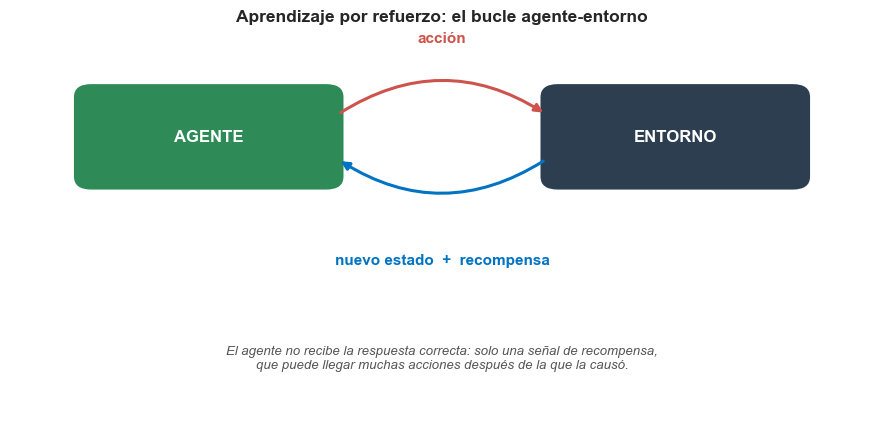

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.6))
ax.set_xlim(0, 100); ax.set_ylim(0, 62); ax.axis("off")

ax.add_patch(mpatches.FancyBboxPatch((8, 38), 30, 15,
             boxstyle="round,pad=0.6,rounding_size=2", facecolor="#2E8B57", edgecolor="none"))
ax.text(23, 45.5, "AGENTE", ha="center", va="center", color="white",
        fontsize=12, fontweight="bold")

ax.add_patch(mpatches.FancyBboxPatch((62, 38), 30, 15,
             boxstyle="round,pad=0.6,rounding_size=2", facecolor="#2C3E50", edgecolor="none"))
ax.text(77, 45.5, "ENTORNO", ha="center", va="center", color="white",
        fontsize=12, fontweight="bold")

ax.annotate("", xy=(62, 49), xytext=(38, 49),
            arrowprops=dict(arrowstyle="-|>", color="#CD534C", lw=2.2,
                            connectionstyle="arc3,rad=-0.32"))
ax.text(50, 60, "acción", ha="center", fontsize=11, color="#CD534C", fontweight="bold")

ax.annotate("", xy=(38, 42), xytext=(62, 42),
            arrowprops=dict(arrowstyle="-|>", color="#0073C2", lw=2.2,
                            connectionstyle="arc3,rad=-0.32"))
ax.text(50, 26, "nuevo estado  +  recompensa", ha="center", fontsize=11,
        color="#0073C2", fontweight="bold")

ax.text(50, 10, "El agente no recibe la respuesta correcta: solo una señal de recompensa,\n"
                "que puede llegar muchas acciones después de la que la causó.",
        ha="center", fontsize=9.5, color="#555", style="italic")
ax.set_title("Aprendizaje por refuerzo: el bucle agente-entorno",
             fontsize=12.5, fontweight="bold")
plt.tight_layout()
plt.show()

**Por qué queda afuera del programa.** El aprendizaje por refuerzo necesita un entorno con
el que interactuar miles o millones de veces: un simulador, un juego, un sistema de
recomendación en producción. En análisis de opinión pública trabajamos con datos
observacionales ya recolectados —una encuesta, un padrón, una serie de resultados
electorales— sobre los que no se puede "actuar" y recibir recompensa. No hay entorno que
responda.

Existen aplicaciones politológicas: modelos de negociación legislativa o de competencia
electoral entre agentes adaptativos, en la tradición de la teoría de juegos computacional.
Pero pertenecen a la modelización de agentes, no al análisis de datos de opinión pública.

**Otras cosas que esta unidad no cubre**, y que conviene nombrar para que sepan que
existen: series de tiempo y forecasting (ARIMA, suavizados exponenciales), redes neuronales
y aprendizaje profundo, y procesamiento de lenguaje natural para análisis de texto — que es
probablemente la extensión más útil para esta materia, y el camino natural después de la
unidad.

## El vocabulario mínimo

Antes de entrar en los métodos, cinco términos que van a aparecer en todos los notebooks.

| Término | Otros nombres | Qué es |
|---|---|---|
| **Instancia** | caso, observación, registro, fila | una unidad de análisis: un país, un encuestado, una mesa |
| **Feature** | variable predictora, atributo, covariable, regresor | una columna que se usa para predecir |
| **Etiqueta** | *target*, variable objetivo, respuesta, $y$ | lo que se quiere predecir |
| **Matriz de diseño** | $X$ | la tabla de instancias × features |
| **Modelo** | estimador, clasificador, regresor | la función ajustada $\hat{f}$ |

En scikit-learn esto se traduce en una convención rígida y muy útil: `X` es una matriz de
$n \times p$ (instancias por features), `y` es un vector de largo $n$, y todo estimador
tiene los métodos `.fit(X, y)` para ajustar y `.predict(X)` para predecir. Todos los
métodos de la unidad —de la regresión regularizada a XGBoost— se usan con esas dos líneas.

In [8]:
# Una matriz de diseño real: la encuesta que usaremos en 9.2 y 9.3b
encuesta = pd.read_excel("../../dataset/encuesta134/134NODUMMY.xlsx")

print(f"instancias (n): {encuesta.shape[0]}")
print(f"columnas      : {encuesta.shape[1]}")
print(f"\netiqueta      : ETIQUETA (identificación política)")
encuesta[["EDAD", "GENERO", "ESTUDIO", "GORRA", "EEUU", "PALESTINA", "ETIQUETA"]].head(6)

instancias (n): 134
columnas      : 39

etiqueta      : ETIQUETA (identificación política)


,EDAD,GENERO,ESTUDIO,GORRA,EEUU,PALESTINA,ETIQUETA
0,25,1,2.0,0,-1.0,1,Peronista
1,24,1,3.0,0,1.0,-1,Liberal
2,23,1,2.0,0,-1.0,0,De izquierda
3,25,0,3.0,0,-1.0,2,Peronista
4,24,1,2.0,1,1.0,1,Peronista
5,24,1,3.0,0,-1.0,0,De izquierda


## El problema central: el error de entrenamiento miente

Acá está la idea que separa al machine learning de todo lo anterior, y la que hay que
entender antes que ninguna otra.

Un modelo suficientemente flexible puede ajustar **cualquier** conjunto de datos a la
perfección. Con suficientes parámetros, se puede pasar una curva exactamente por todos los
puntos, y el error de entrenamiento va a cero. Eso no significa que el modelo haya
aprendido algo: significa que memorizó, incluido el ruido.

Veámoslo. Generamos datos de una relación verdadera conocida —una curva suave— más ruido, y
ajustamos polinomios de complejidad creciente.

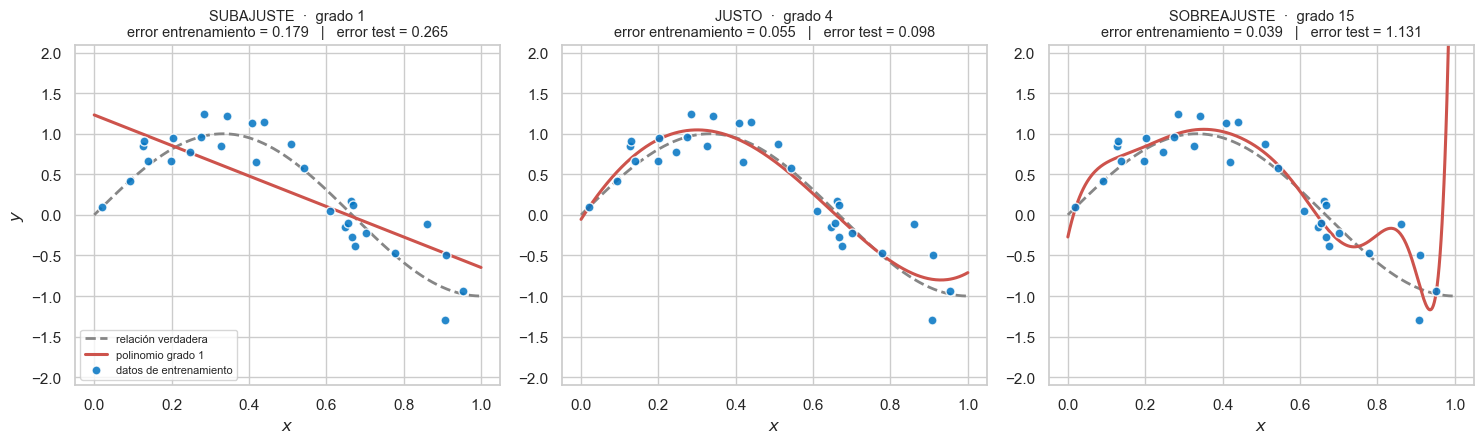

In [9]:
def f_verdadera(x):
    return np.sin(1.5 * np.pi * x)

n = 30
x_tr = np.sort(rng.uniform(0, 1, n))
y_tr = f_verdadera(x_tr) + rng.normal(scale=0.28, size=n)
x_te = np.sort(rng.uniform(0, 1, 200))
y_te = f_verdadera(x_te) + rng.normal(scale=0.28, size=200)

grados = [1, 4, 15]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
malla = np.linspace(0, 1, 400)

for ax, grado in zip(axes, grados):
    modelo = make_pipeline(PolynomialFeatures(grado), LinearRegression())
    modelo.fit(x_tr[:, None], y_tr)
    ax.plot(malla, f_verdadera(malla), color=PALETA[3], lw=2,
            ls="--", label="relación verdadera")
    ax.plot(malla, modelo.predict(malla[:, None]), color=PALETA[2], lw=2.2,
            label=f"polinomio grado {grado}")
    ax.scatter(x_tr, y_tr, s=42, color=PALETA[0], alpha=0.85,
               edgecolor="white", zorder=5, label="datos de entrenamiento")
    e_tr = np.mean((modelo.predict(x_tr[:, None]) - y_tr) ** 2)
    e_te = np.mean((modelo.predict(x_te[:, None]) - y_te) ** 2)
    diagnostico = {1: "SUBAJUSTE", 4: "JUSTO", 15: "SOBREAJUSTE"}[grado]
    ax.set_title(f"{diagnostico}  ·  grado {grado}\n"
                 f"error entrenamiento = {e_tr:.3f}   |   error test = {e_te:.3f}",
                 fontsize=10.5)
    ax.set_ylim(-2.1, 2.1)
    ax.set_xlabel("$x$")
axes[0].set_ylabel("$y$")
axes[0].legend(fontsize=8, loc="lower left")
plt.tight_layout()
plt.show()

Los tres números de error de entrenamiento bajan monótonamente con el grado. Los de test,
no: bajan y después suben.

- **Grado 1** (subajuste, *underfitting*): el modelo es demasiado rígido para la relación
  verdadera. Se equivoca en entrenamiento y en test por la misma razón — no tiene la forma
  adecuada. Su error se llama **sesgo**.
- **Grado 4**: captura la forma sin seguir el ruido. Es el punto que buscamos.
- **Grado 15** (sobreajuste, *overfitting*): pasa casi exactamente por cada punto de
  entrenamiento, con oscilaciones violentas entre ellos. Ajustó el ruido, que por
  definición no se repite en datos nuevos. Su error se llama **varianza**.

Si eligiéramos el modelo por su error de entrenamiento, elegiríamos siempre el grado 15.
Por eso **el error de entrenamiento es inservible para elegir un modelo**, y por eso todo
en machine learning gira alrededor de estimar el error sobre datos que el modelo no vio.

## El compromiso sesgo-varianza

El error esperado de predicción en un punto se descompone en tres partes:

$$ \mathbb{E}\big[(y - \hat{f}(x))^2\big] = \underbrace{\big(\mathbb{E}[\hat f(x)] - f(x)\big)^2}_{\text{sesgo}^2} + \underbrace{\mathbb{E}\big[(\hat f(x) - \mathbb{E}[\hat f(x)])^2\big]}_{\text{varianza}} + \underbrace{\sigma^2}_{\text{irreducible}} $$

- **Sesgo**: cuánto se equivoca sistemáticamente el modelo por ser demasiado simple.
- **Varianza**: cuánto cambiaría el modelo si lo reajustáramos con otra muestra.
- **Error irreducible**: el ruido del fenómeno, que ningún modelo puede eliminar.

Al aumentar la complejidad el sesgo baja y la varianza sube. La suma tiene forma de U, y el
mínimo es el modelo óptimo. **No se puede minimizar las dos a la vez**: es un compromiso, y
elegir un modelo es elegir dónde pararse en esa curva.

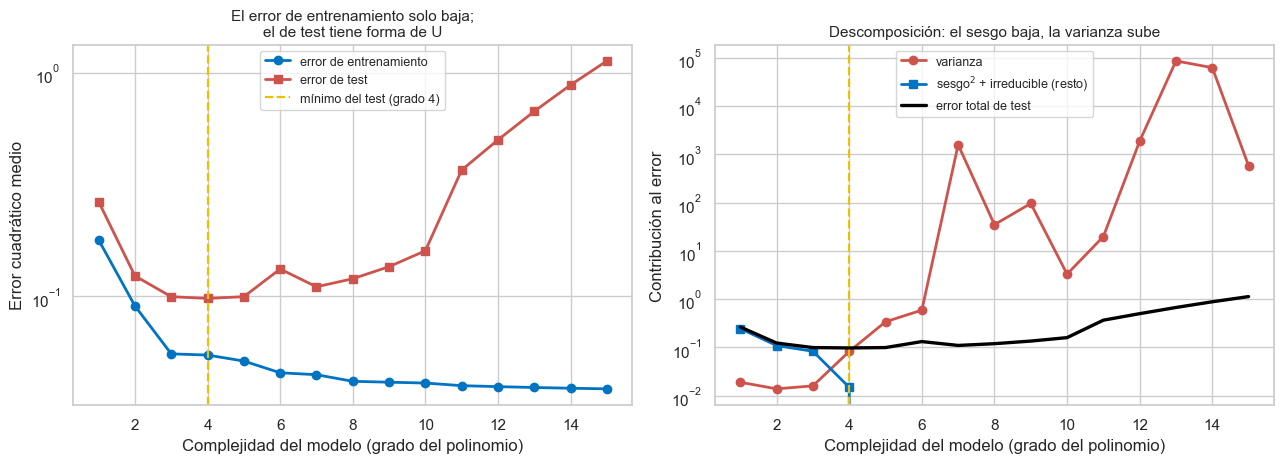

In [10]:
grados_todos = range(1, 16)
err_tr, err_te, varianzas = [], [], []

for grado in grados_todos:
    modelo = make_pipeline(PolynomialFeatures(grado), LinearRegression())
    modelo.fit(x_tr[:, None], y_tr)
    err_tr.append(np.mean((modelo.predict(x_tr[:, None]) - y_tr) ** 2))
    err_te.append(np.mean((modelo.predict(x_te[:, None]) - y_te) ** 2))
    # varianza: reajustar en 40 remuestreos y medir dispersión de las predicciones
    preds = []
    for _ in range(40):
        idx = rng.integers(0, n, n)
        m2 = make_pipeline(PolynomialFeatures(grado), LinearRegression())
        m2.fit(x_tr[idx][:, None], y_tr[idx])
        preds.append(m2.predict(malla[:, None]))
    varianzas.append(np.mean(np.var(np.array(preds), axis=0)))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

ax = axes[0]
ax.plot(list(grados_todos), err_tr, "o-", color=PALETA[0], lw=2, label="error de entrenamiento")
ax.plot(list(grados_todos), err_te, "s-", color=PALETA[2], lw=2, label="error de test")
mejor = int(np.argmin(err_te)) + 1
ax.axvline(mejor, color=PALETA[1], ls="--", lw=1.6, label=f"mínimo del test (grado {mejor})")
ax.set_xlabel("Complejidad del modelo (grado del polinomio)")
ax.set_ylabel("Error cuadrático medio")
ax.set_yscale("log")
ax.set_title("El error de entrenamiento solo baja;\nel de test tiene forma de U", fontsize=11)
ax.legend(fontsize=9)

ax = axes[1]
sesgo_aprox = np.array(err_te) - np.array(varianzas)
ax.plot(list(grados_todos), varianzas, "o-", color=PALETA[2], lw=2, label="varianza")
ax.plot(list(grados_todos), np.clip(sesgo_aprox, 0, None), "s-", color=PALETA[0], lw=2,
        label="sesgo$^2$ + irreducible (resto)")
ax.plot(list(grados_todos), err_te, "-", color="black", lw=2.4, label="error total de test")
ax.axvline(mejor, color=PALETA[1], ls="--", lw=1.6)
ax.set_xlabel("Complejidad del modelo (grado del polinomio)")
ax.set_ylabel("Contribución al error")
ax.set_yscale("log")
ax.set_title("Descomposición: el sesgo baja, la varianza sube", fontsize=11)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

Cada método de la unidad tiene su propia "palanca de complejidad", y ajustarla es siempre
el mismo ejercicio que este gráfico:

| Método | Palanca | Notebook |
|---|---|---|
| Ridge / Lasso / Elastic Net | $\lambda$ (cuánto se penaliza) | `9.1` |
| Regresión logística | $C$ (inverso de la penalización) | `9.2` |
| Árbol de decisión | profundidad máxima, poda | `9.3` |
| Random Forest / XGBoost | cantidad de árboles, tasa de aprendizaje | `9.3` |
| k-means / jerárquico | cantidad de grupos $k$ | `9.4` |
| Reglas de asociación | soporte y confianza mínimos | `9.5` |

## Cómo se estima el error sobre datos no vistos

### La partición

La solución básica es apartar datos antes de empezar y no tocarlos:

- **Entrenamiento** (~60-70%): se usa para ajustar los parámetros del modelo.
- **Validación** (~15-20%): se usa para elegir hiperparámetros y comparar modelos.
- **Test** (~15-20%): se usa **una sola vez**, al final, para reportar la performance.

La razón de separar validación de test es sutil pero importante: si se elige el mejor
hiperparámetro mirando el conjunto de validación cientos de veces, ese conjunto deja de ser
"no visto" — se le ajustó por selección. El test es la única estimación limpia, y se gasta
al usarla.

En la práctica, con muestras chicas —como casi todo lo que hay en ciencia política— apartar
un 20% para test es un lujo caro. Ahí se usa validación cruzada.

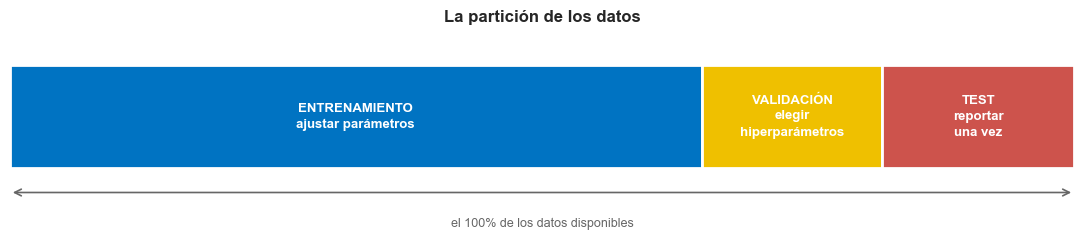

In [11]:
fig, ax = plt.subplots(figsize=(11, 2.6))
ax.set_xlim(0, 100); ax.set_ylim(0, 10); ax.axis("off")

tramos = [("ENTRENAMIENTO\najustar parámetros", 0, 65, PALETA[0]),
          ("VALIDACIÓN\nelegir\nhiperparámetros", 65, 17, PALETA[1]),
          ("TEST\nreportar\nuna vez", 82, 18, PALETA[2])]
for texto, x, w, color in tramos:
    ax.add_patch(mpatches.Rectangle((x, 2), w, 6, facecolor=color, edgecolor="white", lw=2))
    ax.text(x + w/2, 5, texto, ha="center", va="center", color="white",
            fontsize=9.5, fontweight="bold", linespacing=1.4)
ax.annotate("", xy=(100, 0.6), xytext=(0, 0.6),
            arrowprops=dict(arrowstyle="<->", color="#666", lw=1.2))
ax.text(50, -1.4, "el 100% de los datos disponibles", ha="center", fontsize=9, color="#666")
ax.set_title("La partición de los datos", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

### Validación cruzada de $k$ pliegues

Se parten los datos en $k$ bloques (*folds*). Se entrena $k$ veces, cada vez usando $k-1$
bloques para entrenar y el bloque restante para evaluar. El error final es el promedio de
los $k$ errores.

Ventajas sobre una única partición: **cada observación se usa para evaluar exactamente una
vez**, así que se aprovecha toda la muestra, y —lo que más importa— obtenemos $k$
estimaciones del error, o sea una idea de **cuánta incertidumbre** tiene nuestra medición
de performance.

<figure style="text-align:center; margin:1.2em 0;">
  <img src="https://scikit-learn.org/stable/_images/grid_search_cross_validation.png" width="620">
  <figcaption style="font-size:0.88em; color:#555;">
    Validación cruzada de k pliegues. Fuente: documentación de scikit-learn.
  </figcaption>
</figure>

Cuando la etiqueta es categórica y está desbalanceada se usa la versión
**estratificada**, que mantiene en cada pliegue la misma proporción de clases que en el
total. Sin eso, con clases chicas es fácil que un pliegue no contenga ningún caso de alguna
categoría.

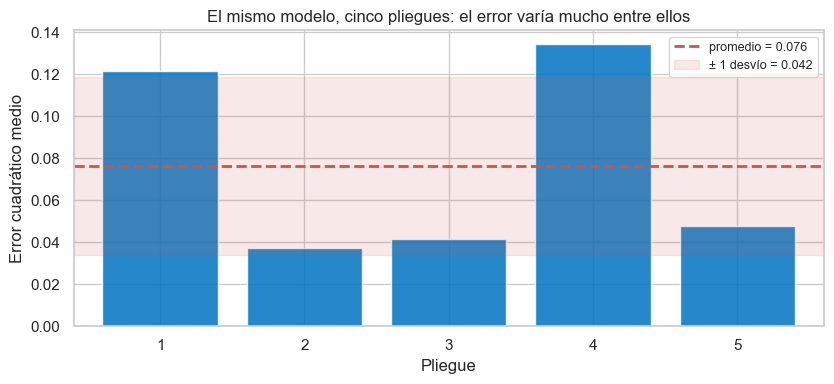

errores por pliegue: [0.122 0.037 0.042 0.134 0.048]
el peor pliegue es 3.6 veces peor que el mejor


In [12]:
# Por qué reportar el desvío entre pliegues y no solo el promedio
modelo = make_pipeline(PolynomialFeatures(4), LinearRegression())
puntajes = cross_val_score(modelo, x_tr[:, None], y_tr,
                           cv=KFold(5, shuffle=True, random_state=SEED),
                           scoring="neg_mean_squared_error")
puntajes = -puntajes

fig, ax = plt.subplots(figsize=(8.5, 4))
ax.bar(range(1, 6), puntajes, color=PALETA[0], alpha=0.85)
ax.axhline(puntajes.mean(), color=PALETA[2], ls="--", lw=2,
           label=f"promedio = {puntajes.mean():.3f}")
ax.fill_between([0.4, 5.6], puntajes.mean() - puntajes.std(),
                puntajes.mean() + puntajes.std(),
                color=PALETA[2], alpha=0.13,
                label=f"± 1 desvío = {puntajes.std():.3f}")
ax.set_xlim(0.4, 5.6)
ax.set_xlabel("Pliegue"); ax.set_ylabel("Error cuadrático medio")
ax.set_title("El mismo modelo, cinco pliegues: el error varía mucho entre ellos")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"errores por pliegue: {np.round(puntajes, 3)}")
print(f"el peor pliegue es {puntajes.max()/puntajes.min():.1f} veces peor que el mejor")

Con $n = 30$ el error va de un pliegue a otro por un factor considerable. Reportar
únicamente el promedio esconde eso, y llevaría a afirmar diferencias entre modelos que son
puro ruido de partición.

**Regla que vamos a seguir en toda la unidad**: siempre que se reporte una métrica de
validación cruzada, se reporta también su desvío entre pliegues. Y si la diferencia entre
dos modelos es menor que ese desvío, se dice que **empatan**, no que uno es mejor.

## El baseline: contra qué se compara

Un número de performance aislado no significa nada. "El modelo tiene 45% de accuracy" no es
bueno ni malo hasta saber cuánto da el modelo más tonto posible.

El **baseline** o modelo nulo es ese modelo tonto:

- En clasificación: predecir siempre la clase más frecuente.
- En regresión: predecir siempre el promedio de $y$.

Cualquier modelo real tiene que ganarle, y por un margen que valga la pena. Veámoslo con la
etiqueta política de la encuesta que usaremos en `9.2` y `9.3b`.

In [13]:
# Las etiquetas de la encuesta, con dos categorías inválidas que hay que descartar
conteo = encuesta["ETIQUETA"].value_counts()
print("Distribución de la etiqueta:")
print(pd.DataFrame({"n": conteo, "%": (conteo / len(encuesta) * 100).round(1)}).to_string())

INVALIDAS = ["Linda", "Es una verga la política"]
valida = encuesta[~encuesta["ETIQUETA"].isin(INVALIDAS)]
print(f"\nDescartando {INVALIDAS} (1 caso cada una): n = {len(valida)}, "
      f"{valida['ETIQUETA'].nunique()} clases")

mayoritaria = valida["ETIQUETA"].value_counts()
print(f"\nClase mayoritaria: '{mayoritaria.index[0]}' con {mayoritaria.iloc[0]} casos")
print(f"BASELINE (predecir siempre la mayoritaria) = "
      f"{mayoritaria.iloc[0] / len(valida) * 100:.1f}% de accuracy")

Distribución de la etiqueta:
                           n     %
ETIQUETA                          
Peronista                 60  44.8
De izquierda              19  14.2
No sabe/ No contesta      18  13.4
Apolitico                 11   8.2
Liberal                   10   7.5
De derecha                 7   5.2
Radical                    7   5.2
Es una verga la política   1   0.7
Linda                      1   0.7

Descartando ['Linda', 'Es una verga la política'] (1 caso cada una): n = 132, 7 clases

Clase mayoritaria: 'Peronista' con 60 casos
BASELINE (predecir siempre la mayoritaria) = 45.5% de accuracy


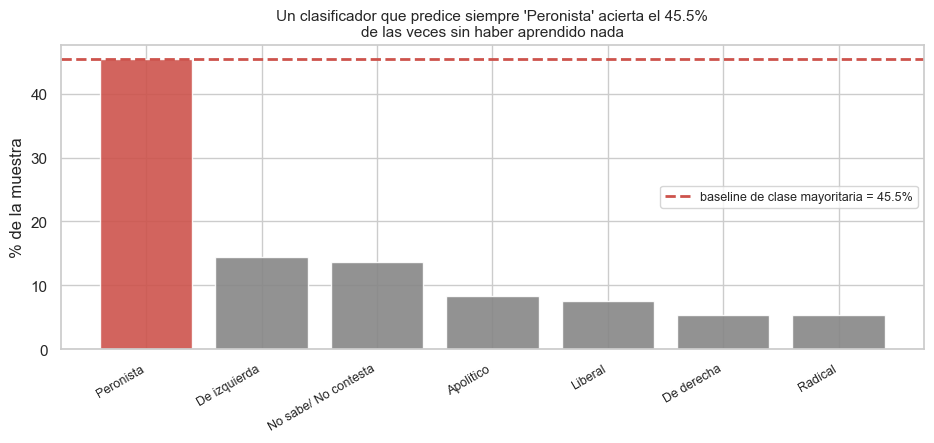

In [14]:
fig, ax = plt.subplots(figsize=(9.5, 4.6))
prop = (mayoritaria / len(valida) * 100)
colores = [PALETA[2]] + [PALETA[3]] * (len(prop) - 1)
ax.bar(range(len(prop)), prop.values, color=colores, alpha=0.9)
ax.axhline(prop.iloc[0], color=PALETA[2], ls="--", lw=2,
           label=f"baseline de clase mayoritaria = {prop.iloc[0]:.1f}%")
ax.set_xticks(range(len(prop)))
ax.set_xticklabels(prop.index, rotation=30, ha="right", fontsize=9)
ax.set_ylabel("% de la muestra")
ax.set_title("Un clasificador que predice siempre 'Peronista' acierta el 45.5%\n"
             "de las veces sin haber aprendido nada", fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

Este número —**45.5%**— es la vara. Un modelo de clasificación política sobre estos datos
que reporte "45% de accuracy" **no aprendió nada**: iguala al modelo que ignora todas las
variables predictoras y contesta siempre lo mismo.

Vale detenerse acá porque es un error extraordinariamente común, y no solo entre
principiantes. Aparece cada vez que se reporta un accuracy sin baseline y se lo califica de
"alto para ciencias sociales". La pregunta correcta nunca es *¿es alto el número?* sino
*¿cuánto le gana al modelo nulo?*

En `9.2` y `9.3b` vamos a comparar contra este 45.5% en cada tabla de resultados.

In [15]:
# scikit-learn tiene el baseline como estimador, para meterlo en cualquier comparación
Xb = pd.get_dummies(valida[["GENERO", "EDAD", "GORRA", "EEUU", "PALESTINA"]]
                    .fillna(valida[["GENERO", "EDAD", "GORRA", "EEUU", "PALESTINA"]].median(
                        numeric_only=True)))
yb = valida["ETIQUETA"]

for estrategia in ["most_frequent", "stratified", "uniform"]:
    d = DummyClassifier(strategy=estrategia, random_state=SEED)
    s = cross_val_score(d, Xb, yb, cv=5, scoring="accuracy")
    print(f"DummyClassifier('{estrategia}'):  accuracy = {s.mean():.3f} ± {s.std():.3f}")

DummyClassifier('most_frequent'):  accuracy = 0.455 ± 0.008
DummyClassifier('stratified'):  accuracy = 0.281 ± 0.033
DummyClassifier('uniform'):  accuracy = 0.152 ± 0.054


## Las métricas

### Clasificación: la matriz de confusión

Todo empieza acá. Para un problema de dos clases, cruzar lo observado con lo predicho da
cuatro celdas:

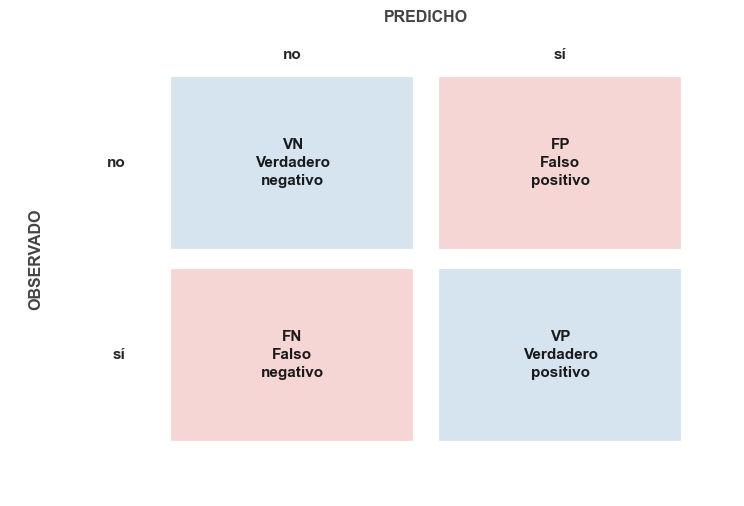

In [16]:
fig, ax = plt.subplots(figsize=(7.6, 5.2))
ax.set_xlim(0, 10); ax.set_ylim(0, 8.6); ax.axis("off")

celdas = [
    (2.2, 4.6, "VN\nVerdadero\nnegativo", "#D6E4F0", "Predijo no · era no"),
    (5.9, 4.6, "FP\nFalso\npositivo", "#F6D6D5", "Predijo sí · era no\n(error tipo I)"),
    (2.2, 1.0, "FN\nFalso\nnegativo", "#F6D6D5", "Predijo no · era sí\n(error tipo II)"),
    (5.9, 1.0, "VP\nVerdadero\npositivo", "#D6E4F0", "Predijo sí · era sí"),
]
for x, y, texto, color, _ in celdas:
    ax.add_patch(mpatches.Rectangle((x, y), 3.4, 3.3, facecolor=color,
                                    edgecolor="white", lw=3))
    ax.text(x + 1.7, y + 1.65, texto, ha="center", va="center", fontsize=11,
            fontweight="bold", color="#1a1a1a", linespacing=1.35)

ax.text(3.9, 8.2, "no", ha="center", fontsize=11, fontweight="bold")
ax.text(7.6, 8.2, "sí", ha="center", fontsize=11, fontweight="bold")
ax.text(5.75, 8.9, "PREDICHO", ha="center", fontsize=11.5, fontweight="bold", color="#444")
ax.text(1.6, 6.25, "no", ha="right", va="center", fontsize=11, fontweight="bold")
ax.text(1.6, 2.65, "sí", ha="right", va="center", fontsize=11, fontweight="bold")
ax.text(0.35, 4.45, "OBSERVADO", ha="center", va="center", fontsize=11.5,
        fontweight="bold", rotation=90, color="#444")
plt.tight_layout()
plt.show()

De esas cuatro celdas salen todas las métricas:

$$ \text{Exactitud (accuracy)} = \frac{VP + VN}{VP + VN + FP + FN} \qquad
   \text{Precisión} = \frac{VP}{VP + FP} $$

$$ \text{Sensibilidad (recall)} = \frac{VP}{VP + FN} \qquad
   F_1 = 2 \cdot \frac{\text{precisión} \cdot \text{recall}}{\text{precisión} + \text{recall}} $$

En castellano, y con un ejemplo de campaña donde "positivo" es *este votante es
persuadible*:

- **Exactitud**: qué proporción del total clasifiqué bien. Es la métrica más intuitiva y la
  más engañosa con clases desbalanceadas, como acabamos de ver.
- **Precisión**: de los que marqué como persuadibles, cuántos lo eran. Importa cuando
  actuar sobre un falso positivo **cuesta** — cada llamada telefónica se paga.
- **Recall**: de todos los persuadibles que existen, a cuántos detecté. Importa cuando
  **perder** un caso positivo es lo caro — un votante persuadible al que nunca contactamos.
- **$F_1$**: la media armónica de las dos. Se usa cuando ninguna de las dos domina y se
  quiere un solo número.

Precisión y recall están en tensión: se puede subir una bajando la otra moviendo el umbral
de decisión.

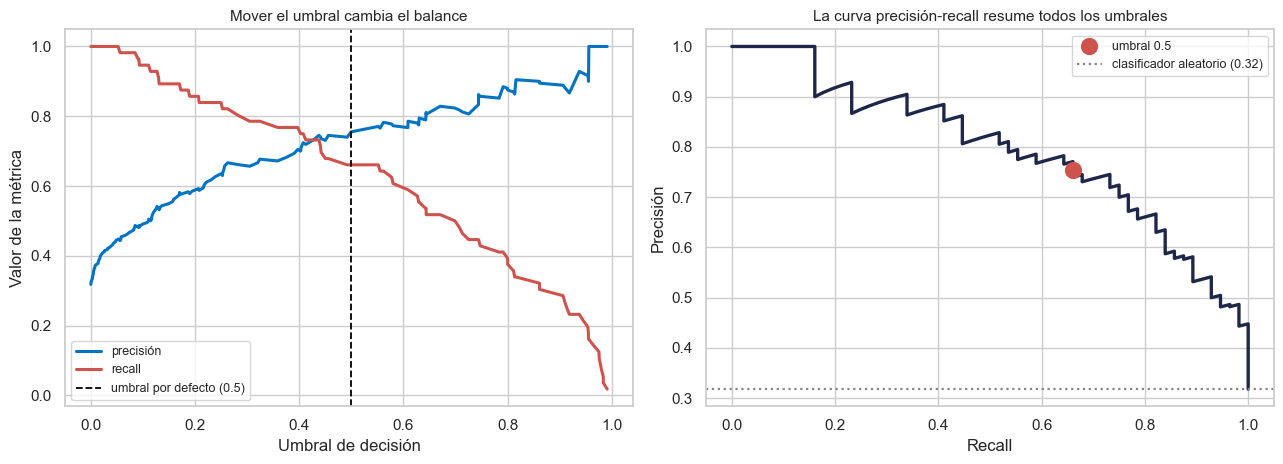

In [17]:
# El umbral de decisión mueve precisión y recall en direcciones opuestas
from sklearn.metrics import precision_recall_curve

Xs = np.vstack([rng.normal([-0.6, -0.3], 1.05, (300, 2)),
                rng.normal([0.9, 0.7], 1.05, (140, 2))])
ys = np.r_[np.zeros(300), np.ones(140)]
Xtr, Xte, ytr, yte = train_test_split(Xs, ys, test_size=0.4,
                                      random_state=SEED, stratify=ys)
mod = LogisticRegression().fit(Xtr, ytr)
probs = mod.predict_proba(Xte)[:, 1]
prec, rec, umbrales = precision_recall_curve(yte, probs)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

axes[0].plot(umbrales, prec[:-1], lw=2.2, color=PALETA[0], label="precisión")
axes[0].plot(umbrales, rec[:-1], lw=2.2, color=PALETA[2], label="recall")
axes[0].axvline(0.5, color="black", ls="--", lw=1.3, label="umbral por defecto (0.5)")
axes[0].set_xlabel("Umbral de decisión"); axes[0].set_ylabel("Valor de la métrica")
axes[0].set_title("Mover el umbral cambia el balance", fontsize=11)
axes[0].legend(fontsize=9)

axes[1].plot(rec, prec, lw=2.4, color=PALETA[4])
i = np.argmin(np.abs(umbrales - 0.5))
axes[1].scatter([rec[i]], [prec[i]], s=130, color=PALETA[2], zorder=5,
                label="umbral 0.5")
axes[1].axhline(ys.mean(), color=PALETA[3], ls=":", lw=1.6,
                label=f"clasificador aleatorio ({ys.mean():.2f})")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precisión")
axes[1].set_title("La curva precisión-recall resume todos los umbrales", fontsize=11)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

### Con más de dos clases: macro, micro y balanceada

Cuando hay $K$ clases, precisión y recall se calculan por clase y después se promedian. Cómo
se promedia importa mucho:

- **Micro**: junta todos los VP, FP y FN de todas las clases y calcula una sola métrica. Le
  da más peso a las clases grandes. Con clases desbalanceadas coincide con la exactitud.
- **Macro**: calcula la métrica en cada clase y promedia sin ponderar. **Cada clase pesa
  igual**, sin importar su tamaño.
- **Ponderada**: promedia pesando por la frecuencia de cada clase.

Para nuestro problema de siete etiquetas políticas donde una concentra el 45% y varias
tienen menos de diez casos, la métrica honesta es el **$F_1$ macro**: si el modelo ignora
por completo a los radicales, el macro lo castiga y el micro casi no lo nota.

También usaremos la **exactitud balanceada**, que es el promedio del recall por clase y
tiene la propiedad cómoda de que el baseline de clase mayoritaria da $1/K$.

In [18]:
# El mismo modelo, tres lecturas distintas según cómo se promedie
ycierto = np.array(["A"] * 60 + ["B"] * 20 + ["C"] * 12 + ["D"] * 8)
ypred_todo_a = np.array(["A"] * 100)   # el clasificador perezoso

print("Un clasificador que predice SIEMPRE la clase mayoritaria 'A':\n")
print(f"  exactitud            = {accuracy_score(ycierto, ypred_todo_a):.3f}")
print(f"  F1 micro             = {f1_score(ycierto, ypred_todo_a, average='micro'):.3f}")
print(f"  F1 macro             = {f1_score(ycierto, ypred_todo_a, average='macro'):.3f}")
print(f"  F1 ponderado         = {f1_score(ycierto, ypred_todo_a, average='weighted'):.3f}")
print(f"  exactitud balanceada = {balanced_accuracy_score(ycierto, ypred_todo_a):.3f}")
print(f"\n  (con {len(set(ycierto))} clases, 1/K = {1/len(set(ycierto)):.3f})")
print("\nLa exactitud dice 0.60 y el F1 macro dice 0.19. El segundo tiene razón.")

Un clasificador que predice SIEMPRE la clase mayoritaria 'A':

  exactitud            = 0.600
  F1 micro             = 0.600
  F1 macro             = 0.188
  F1 ponderado         = 0.450
  exactitud balanceada = 0.250

  (con 4 clases, 1/K = 0.250)

La exactitud dice 0.60 y el F1 macro dice 0.19. El segundo tiene razón.


### Regresión

Para etiquetas cuantitativas:

$$ \text{RMSE} = \sqrt{\frac{1}{n}\sum_i (y_i - \hat y_i)^2} \qquad
   \text{MAE} = \frac{1}{n}\sum_i |y_i - \hat y_i| \qquad
   R^2 = 1 - \frac{\sum_i (y_i - \hat y_i)^2}{\sum_i (y_i - \bar y)^2} $$

- **RMSE**: está en las unidades de $y$, lo cual la hace interpretable. Penaliza los errores
  grandes de forma cuadrática, así que es sensible a valores atípicos.
- **MAE**: también en unidades de $y$, y más robusta a atípicos.
- **$R^2$**: la proporción de la varianza explicada. Su virtud es no tener unidades; su
  trampa es que **calculado fuera de la muestra puede ser negativo**, y eso significa algo
  muy concreto: el modelo predice peor que la media de $y$. Vamos a ver un caso real de eso
  en `9.1`.

## Fugas de información

Una **fuga de información** (*data leakage*) ocurre cuando al modelo entra, por alguna vía,
información del conjunto de evaluación. El síntoma es una performance sospechosamente buena
que se derrumba al usar el modelo de verdad.

Es el error más costoso del machine learning aplicado, porque no produce ningún mensaje de
error: produce un resultado excelente y falso. Cuatro formas de cometerlo, en orden de qué
tan fácil es no darse cuenta.

### 1. Preprocesar antes de partir

Estandarizar, imputar faltantes o seleccionar variables usando **toda** la muestra y recién
después partir en entrenamiento y test. La media y el desvío con que se estandarizó ya
contienen información de los casos de test.

In [19]:
# Cuánto optimismo introduce estandarizar antes de partir, en el caso extremo p >> n
n_casos, p_vars = 60, 400
X_ruido = rng.normal(size=(n_casos, p_vars))
y_ruido = rng.normal(size=n_casos)          # y NO tiene ninguna relación con X

from sklearn.feature_selection import SelectKBest, f_regression

# --- MAL: seleccionar las 5 "mejores" variables mirando TODA la muestra
sel = SelectKBest(f_regression, k=5).fit(X_ruido, y_ruido)
X_elegidas = sel.transform(X_ruido)
mal = cross_val_score(LinearRegression(), X_elegidas, y_ruido,
                      cv=KFold(5, shuffle=True, random_state=SEED), scoring="r2")

# --- BIEN: la selección ocurre dentro de cada pliegue
bien = cross_val_score(
    make_pipeline(SelectKBest(f_regression, k=5), LinearRegression()),
    X_ruido, y_ruido, cv=KFold(5, shuffle=True, random_state=SEED), scoring="r2")

print("y es ruido puro: no hay NADA que predecir. El R2 honesto debe ser <= 0.\n")
print(f"  Selección fuera del pliegue (MAL) : R2 = {mal.mean():+.3f}")
print(f"  Selección dentro del pliegue (BIEN): R2 = {bien.mean():+.3f}")
print("\nLa primera cifra es enteramente ficticia y sale de un dato inexistente.")

y es ruido puro: no hay NADA que predecir. El R2 honesto debe ser <= 0.

  Selección fuera del pliegue (MAL) : R2 = +0.117
  Selección dentro del pliegue (BIEN): R2 = -0.482

La primera cifra es enteramente ficticia y sale de un dato inexistente.


El primer número es positivo sobre datos donde **no hay ninguna señal**. Con 400 variables
aleatorias y 60 casos, siempre hay unas cuantas que correlacionan con $y$ por puro azar; si
las elegimos mirando toda la muestra, esa correlación espuria está también en los pliegues
de validación.

La defensa es estructural, no de disciplina: **todo el preprocesamiento va dentro de un
`Pipeline`**, y el `Pipeline` se pasa a la validación cruzada. Así scikit-learn garantiza
que cada paso se ajuste solo con los datos de entrenamiento de cada pliegue. Es la razón por
la que en toda la unidad no vamos a ver un `StandardScaler().fit_transform(X)` suelto.

### 2. El predictor que es la etiqueta con otro nombre

El más difícil de detectar, porque no hay error de código: hay una variable que contiene la
respuesta. Un caso real, con los datos de QOG que usaremos en `9.1` y `9.4`.

In [20]:
qog = pd.read_stata("../../dataset/QOG/qog_bas_cs_jan26.dta", convert_categoricals=False)

# Objetivo: el índice de percepción de corrupción de Transparency International
sub = qog[["wbgi_cce", "ti_cpi"]].dropna()
r = sub["wbgi_cce"].corr(sub["ti_cpi"])

X1 = sub[["wbgi_cce"]]
r2 = cross_val_score(LinearRegression(), X1, sub["ti_cpi"],
                     cv=KFold(5, shuffle=True, random_state=SEED), scoring="r2").mean()

print(f"Predecir ti_cpi usando solo wbgi_cce:")
print(f"  correlación = {r:.3f}")
print(f"  R2 de validación cruzada = {r2:.3f}   con UNA sola variable")
print("\n¿Descubrimos la causa de la corrupción? No.")
print("wbgi_cce (Control of Corruption, Banco Mundial) es un índice compuesto")
print("que se construye agregando fuentes, y una de esas fuentes ES el CPI.")
print("Es la misma medición con otro nombre.")

Predecir ti_cpi usando solo wbgi_cce:
  correlación = 0.992
  R2 de validación cruzada = 0.983   con UNA sola variable

¿Descubrimos la causa de la corrupción? No.
wbgi_cce (Control of Corruption, Banco Mundial) es un índice compuesto
que se construye agregando fuentes, y una de esas fuentes ES el CPI.
Es la misma medición con otro nombre.


Ningún procedimiento estadístico puede detectar esto. Solo se detecta **leyendo la
documentación de las variables**: saber cómo se construyó cada indicador es parte del
trabajo, y en datos secundarios agregados —que es casi todo lo que usa la política
comparada— los índices compuestos se alimentan unos de otros todo el tiempo.

Regla práctica: ante un $R^2$ de 0.98 o un accuracy de 0.99, la primera hipótesis nunca es
"qué buen modelo".

### 3. Información del futuro

Usar como predictor algo que en el momento de predecir todavía no se conoce. El ejemplo
clásico está en el material del que salió esta unidad: un modelo para predecir si un cliente
contrata un producto telefónico, entre cuyos predictores figuraba **la duración de la
llamada**. La duración solo se conoce cuando la llamada terminó, o sea cuando ya se sabe la
respuesta. El modelo tenía una performance excelente y era inservible.

En análisis electoral: predecir el resultado de una mesa usando columnas derivadas del
propio conteo de votos.

### 4. Duplicados y dependencia entre observaciones

Si el mismo caso aparece en entrenamiento y en test —registros duplicados, varias
observaciones del mismo individuo, mesas de la misma escuela— la partición no separa nada.
La validación cruzada estándar supone observaciones independientes; cuando hay estructura de
grupo hay que usar particiones que respeten los grupos (`GroupKFold`).

## Cierre aplicado: elegir el método

Todo lo anterior sirve para una decisión concreta que se toma al empezar cualquier proyecto:
**¿qué método corresponde a este problema?**

La respuesta se sigue de cuatro preguntas, en este orden.

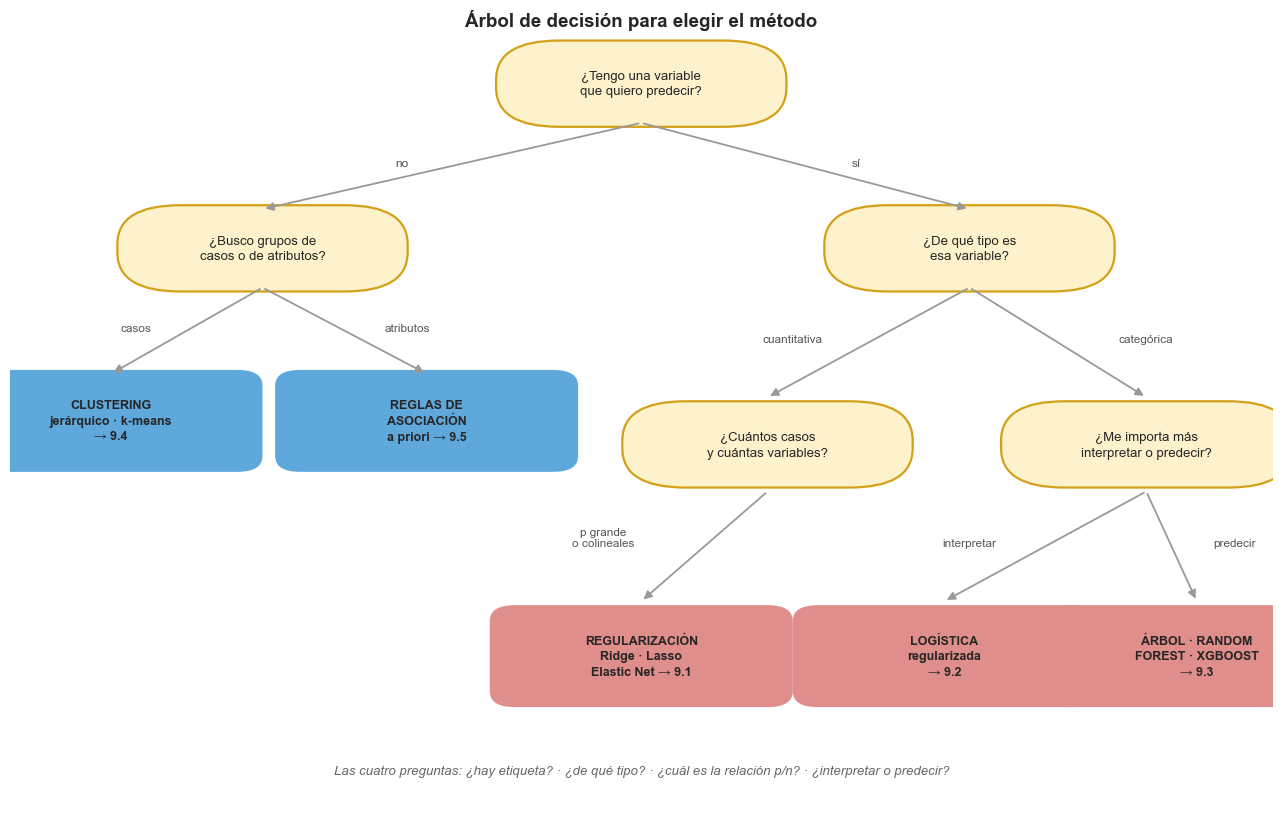

In [21]:
fig, ax = plt.subplots(figsize=(13, 8.4))
ax.set_xlim(0, 100); ax.set_ylim(0, 100); ax.axis("off")

def rombo(x, y, texto, size=9.5):
    ax.add_patch(mpatches.FancyBboxPatch((x - 11, y - 5), 22, 10,
                 boxstyle="round,pad=0.5,rounding_size=5", facecolor="#FDF2CC",
                 edgecolor="#D4A017", lw=1.6))
    ax.text(x, y, texto, ha="center", va="center", fontsize=size, linespacing=1.4)

def hoja(x, y, texto, color="#D6E4F0", size=9):
    ax.add_patch(mpatches.FancyBboxPatch((x - 11.5, y - 6), 23, 12,
                 boxstyle="round,pad=0.5,rounding_size=2", facecolor=color,
                 edgecolor="none"))
    ax.text(x, y, texto, ha="center", va="center", fontsize=size,
            linespacing=1.4, fontweight="bold")

def link(x1, y1, x2, y2, etiqueta="", dx=0):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="-|>", color="#999", lw=1.3))
    if etiqueta:
        ax.text((x1 + x2) / 2 + dx, (y1 + y2) / 2, etiqueta, fontsize=8.5,
                color="#555", ha="center",
                bbox=dict(boxstyle="round,pad=0.18", fc="white", ec="none"))

rombo(50, 93, "¿Tengo una variable\nque quiero predecir?")

# --- rama no supervisada
rombo(20, 72, "¿Busco grupos de\ncasos o de atributos?")
link(50, 88, 20, 77, "no", -4)
hoja(8, 50, "CLUSTERING\njerárquico · k-means\n→ 9.4", "#5FA8DC")
hoja(33, 50, "REGLAS DE\nASOCIACIÓN\na priori → 9.5", "#5FA8DC")
link(20, 67, 8, 56, "casos", -4)
link(20, 67, 33, 56, "atributos", 5)

# --- rama supervisada
rombo(76, 72, "¿De qué tipo es\nesa variable?")
link(50, 88, 76, 77, "sí", 4)

rombo(60, 47, "¿Cuántos casos\ny cuántas variables?")
link(76, 67, 60, 53, "cuantitativa", -6)
rombo(90, 47, "¿Me importa más\ninterpretar o predecir?")
link(76, 67, 90, 53, "categórica", 7)

hoja(50, 20, "REGULARIZACIÓN\nRidge · Lasso\nElastic Net → 9.1", "#E08E8B")
hoja(74, 20, "LOGÍSTICA\nregularizada\n→ 9.2", "#E08E8B")
hoja(94, 20, "ÁRBOL · RANDOM\nFOREST · XGBOOST\n→ 9.3", "#E08E8B")

link(60, 41, 50, 27, "p grande\no colineales", -8)
link(90, 41, 74, 27, "interpretar", -6)
link(90, 41, 94, 27, "predecir", 5)

ax.text(50, 5, "Las cuatro preguntas: ¿hay etiqueta? · ¿de qué tipo? · "
               "¿cuál es la relación p/n? · ¿interpretar o predecir?",
        ha="center", fontsize=9.5, color="#666", style="italic")
ax.set_title("Árbol de decisión para elegir el método", fontsize=13.5,
             fontweight="bold", pad=2)
plt.tight_layout()
plt.show()

In [22]:
def elegir_metodo(tiene_etiqueta, tipo_etiqueta=None, n_casos=None,
                  n_variables=None, prioridad=None, agrupar=None):
    '''Recomienda un método de esta unidad a partir de las cuatro preguntas.

    tiene_etiqueta : bool   ¿hay una variable a predecir?
    tipo_etiqueta  : str    'cuantitativa' o 'categorica'
    n_casos        : int    cantidad de observaciones
    n_variables    : int    cantidad de predictores candidatos
    prioridad      : str    'interpretar' o 'predecir'
    agrupar        : str    'casos' o 'atributos'  (solo si no hay etiqueta)
    '''
    if not tiene_etiqueta:
        if agrupar == "atributos":
            return ("Reglas de asociación (a priori)", "9.5",
                    "Buscás qué atributos co-ocurren, no qué casos se parecen.")
        return ("Clustering jerárquico y/o k-means", "9.4",
                "Sin etiqueta y agrupando casos. Jerárquico si querés ver la "
                "estructura de anidamiento; k-means si ya sabés cuántos grupos "
                "buscás y tenés muchos casos.")

    if tipo_etiqueta == "cuantitativa":
        if n_variables and n_casos and n_variables > n_casos / 10:
            return ("Regresión regularizada (Lasso o Elastic Net)", "9.1",
                    f"Con {n_variables} predictores y {n_casos} casos, MCO sobreajusta. "
                    "Lasso además selecciona variables.")
        return ("Regresión lineal múltiple, y Ridge si hay colinealidad", "9.1 y unidad 5",
                "Pocas variables respecto de los casos: MCO alcanza. Revisá el VIF.")

    if tipo_etiqueta == "categorica":
        if prioridad == "interpretar":
            return ("Regresión logística regularizada", "9.2",
                    "Da odds ratios interpretables y una frontera de decisión simple.")
        if n_casos and n_casos < 300:
            return ("Regresión logística regularizada", "9.2",
                    f"Con {n_casos} casos, un ensamble no tiene datos suficientes para "
                    "superar a un modelo lineal. Compará siempre contra el baseline.")
        return ("Random Forest o XGBoost", "9.3",
                "Muchos casos y prioridad en la predicción: los ensambles capturan "
                "interacciones no lineales. Usá importancia por permutación para leerlos.")

    return ("Faltan datos para decidir", "—", "Revisá los argumentos.")


problemas = [
    ("Predecir el % de votos de un partido por circuito, con 40 variables censales y 167 circuitos",
     dict(tiene_etiqueta=True, tipo_etiqueta="cuantitativa", n_casos=167, n_variables=40)),
    ("Explicar qué atributos hacen que alguien se identifique como peronista (n=132)",
     dict(tiene_etiqueta=True, tipo_etiqueta="categorica", n_casos=132, prioridad="interpretar")),
    ("Predecir el partido ganador en cada una de 7.268 mesas",
     dict(tiene_etiqueta=True, tipo_etiqueta="categorica", n_casos=7268, prioridad="predecir")),
    ("Encontrar tipos de régimen político entre 194 países",
     dict(tiene_etiqueta=False, agrupar="casos")),
    ("Ver qué proyectos de ley se votan juntos en la cámara",
     dict(tiene_etiqueta=False, agrupar="atributos")),
]

for descripcion, argumentos in problemas:
    metodo, nb, razon = elegir_metodo(**argumentos)
    print(f"» {descripcion}")
    print(f"   → {metodo}  [notebook {nb}]")
    print(f"     {razon}\n")

» Predecir el % de votos de un partido por circuito, con 40 variables censales y 167 circuitos
   → Regresión regularizada (Lasso o Elastic Net)  [notebook 9.1]
     Con 40 predictores y 167 casos, MCO sobreajusta. Lasso además selecciona variables.

» Explicar qué atributos hacen que alguien se identifique como peronista (n=132)
   → Regresión logística regularizada  [notebook 9.2]
     Da odds ratios interpretables y una frontera de decisión simple.

» Predecir el partido ganador en cada una de 7.268 mesas
   → Random Forest o XGBoost  [notebook 9.3]
     Muchos casos y prioridad en la predicción: los ensambles capturan interacciones no lineales. Usá importancia por permutación para leerlos.

» Encontrar tipos de régimen político entre 194 países
   → Clustering jerárquico y/o k-means  [notebook 9.4]
     Sin etiqueta y agrupando casos. Jerárquico si querés ver la estructura de anidamiento; k-means si ya sabés cuántos grupos buscás y tenés muchos casos.

» Ver qué proyectos de ley se

El árbol es una guía, no una ley. Dos advertencias sobre cómo usarlo:

- **Casi siempre conviene correr más de un método.** El valor de comparar un logit contra un
  Random Forest no es quedarse con el que gana, sino ver *cuánto* gana: si el ensamble no le
  saca ventaja al modelo lineal, es evidencia de que la relación es aproximadamente lineal, y
  eso es un hallazgo.
- **El primer modelo siempre es el baseline.** Antes del logit y antes del bosque, el
  `DummyClassifier`. Si nada le gana, el problema no está en el método.

## El mapa de la unidad

| Notebook | Método | Tipo | Datos | Pregunta |
|---|---|---|---|---|
| `9.1` | Ridge, Lasso, Elastic Net | supervisado · regresión | QOG, 194 países | ¿Qué explica la corrupción percibida, y qué países se desvían de su estructura? |
| `9.2` | Regresión logística | supervisado · clasificación | Encuesta, 132 casos | ¿Se puede predecir la identificación política a partir de opiniones y demografía? |
| `9.3` | Árbol, Random Forest, XGBoost | supervisado · clasificación | Mesas CABA 2025, 7.233 | ¿Le ganan los ensambles al modelo lineal? |
| `9.3b` | los mismos métodos | supervisado · clasificación | Encuesta, 132 casos | ¿La respuesta cambia con el n que uno tiene de verdad? |
| `9.4` | Jerárquico, k-means, PCA | no supervisado · clustering | QOG, 194 países | ¿Qué tipos de régimen emergen de los datos, y quiénes son los pares reales de Argentina? |
| `9.5` | A priori | no supervisado · asociación | Votaciones legislativas | ¿Qué proyectos se votan juntos, y quiénes son los legisladores pivote? |

Cada notebook retoma en dos o tres líneas el marco de este y va directo al método. El
vocabulario, el sobreajuste, la validación cruzada, el baseline, las métricas y las fugas de
información **no se vuelven a explicar**: se usan.

## Síntesis

1. El machine learning cambia la pregunta de *¿cuál es el efecto de X sobre Y?* a *¿qué tan
   bien anticipo Y en casos nuevos?* Son dos culturas estadísticas, y en ciencia política
   conviene no abandonar la primera.

2. La división del terreno es por la información disponible: **supervisado** (hay etiqueta),
   **no supervisado** (no hay), **por refuerzo** (hay recompensa, y queda fuera del
   programa). Dentro del supervisado, el tipo de la etiqueta decide entre **regresión** y
   **clasificación**.

3. **El error de entrenamiento es inservible para elegir un modelo.** Siempre baja con la
   complejidad. Lo que importa es el error sobre datos no vistos, que tiene forma de U:
   sesgo cuando el modelo es muy simple, varianza cuando es muy flexible.

4. Se estima ese error con particiones y, con muestras chicas, con **validación cruzada**. Y
   se reporta **siempre con su desvío entre pliegues**: si la diferencia entre dos modelos es
   menor que el desvío, empatan.

5. **Ninguna métrica significa nada sin baseline.** En nuestra encuesta, predecir siempre
   "Peronista" acierta el 45.5%. Un modelo con 45% de accuracy no aprendió nada.

6. Con clases desbalanceadas, la exactitud engaña: usar **$F_1$ macro** y **exactitud
   balanceada**, que hacen visible a las clases chicas.

7. Las **fugas de información** producen resultados excelentes y falsos. La defensa es
   estructural —todo el preprocesamiento dentro de un `Pipeline`— más una que no se puede
   automatizar: leer cómo se construyó cada variable.

## Formulario de referencia

Para tener a mano durante la unidad: funciones de pérdida, métricas, álgebra lineal y
distribuciones.

<figure style="text-align:center; margin:1.2em 0;">
  <img src="media/ml_cheatsheet.jpeg" width="700">
</figure>